# Spindle vs. Slow-Wave Infraslow Analysis Demo (N2 and N3)

Downstream analysis/visualization notebook over `infraslow.pipeline`'s already-computed
per-subject ISFS spectrum and phase features (see `src/scripts/preprocessing.py` for how
the underlying `.npz`/`.csv` artifacts under `/scratch/users/chaisaen/usleep_dryrun_v2/data/`
were generated). No EEG filtering, spindle/slow-wave detection, or envelope computation
happens here -- every number below comes from `infraslow.pipeline.pipeline.run_subject_state_channel`
and `infraslow.stat.state_comparison`, reused unmodified from the rest of the project.

This is the **event-type** counterpart of `demo_plot_and_compared_{sigma,delta}.ipynb`:
those two notebooks each fix an event type (spindle or slow-wave) and compare **N2 vs N3**;
this notebook fixes the sleep state and compares **spindle vs slow-wave** instead, run once
for N2 and once for N3. `run_subject_state_channel(..., event="spindle")` pairs sigma-band
ISFS spectra with `spindle_bouts.npz["spindle"]`/`spindle_yasa.csv["Peak"]` events;
`event="sw"` pairs delta-band ISFS spectra with `sw_bouts.npz["sw"]`/`sw_yasa.csv["NegPeak"]`
events -- everything downstream (feature names, phase-bin machinery, statistics) is
otherwise identical between the two event types.

Within each state, compares **spindle vs slow-wave** on channel **C3** across every
eligible subject (sorted by id) with usable data for *both* event types in that state, or
the first `N_SUBJECTS` if that's set to a number instead of `None`. The N2 and N3 subject
pools are independent -- a subject only needs to be usable for both events within the state
being analyzed, not across both states.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from infraslow.pipeline import pipeline as ppl
from infraslow.pipeline import phase as pph
from infraslow.processing.infraslow import (
    DEFAULT_INFRASLOW_BAND,
    DEFAULT_BASELINE_BAND,
    bigaussian,
    fit_isfs,
)
from infraslow.stat import state_comparison as stc

# infraslow.pipeline.pipeline transitively imports infraslow.pipeline.figures, which
# calls matplotlib.use("Agg") at import time (a headless-safe default for the batch
# pipeline) -- that forces a non-interactive backend, silently overriding an earlier
# `%matplotlib inline`. Issuing the magic here, after those imports, re-enables inline
# figure display in this notebook without touching the pre-existing pipeline module.
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

SPINDLE_COLOR, LSPINDLE_COLOR = '#2a6f97', '#a9cce3'
SW_COLOR, LSW_COLOR = '#c1121f', '#f1a7a7'
COLORS = {"spindle": (SPINDLE_COLOR, LSPINDLE_COLOR), "sw": (SW_COLOR, LSW_COLOR)}
EVENT_LABELS = {"spindle": "Spindle", "sw": "Slow-wave"}

DATA_DIR = Path("/scratch/users/chaisaen/usleep_dryrun_v2/data")
CHANNEL = "C3"
# EVENTS is the paired factor for this notebook (vs. STATES in the sigma/delta
# notebooks) -- "spindle" pairs sigma-band ISFS spectra with
# spindle_bouts.npz["spindle"]/spindle_yasa.csv["Peak"]; "sw" pairs delta-band ISFS spectra
# with sw_bouts.npz["sw"]/sw_yasa.csv["NegPeak"]. See run_subject_state_channel's
# `event` param / infraslow.pipeline.pipeline._EVENT_SPECS.
EVENTS = ("spindle", "sw")
# DATA_DIR holds 169,740 subject directories -- None (scan/use everything) is not
# practical here (each candidate costs several file reads + a curve_fit per event, and
# this notebook scans twice, once per state). N_SUBJECTS caps how many *usable*
# subjects to keep per state; CANDIDATE_LIMIT caps how many candidates get scanned to
# find them -- set N_SUBJECTS to an int for a faster interactive run.
N_SUBJECTS = 2000
CANDIDATE_LIMIT = None
verbose = True  # print live scan progress (one line per subject scanned)

## 2. Helper Functions

The spindle-vs-slow-wave analysis below (subject selection, spectral analysis, phase
analysis, peak-frequency distribution, statistical comparison) is run twice -- once for
N2, once for N3 -- on otherwise identical logic, so it's factored into functions here and
called once per state in Sections 3 and 4. Each function mirrors the corresponding section
of `demo_plot_and_compared_{sigma,delta}.ipynb` almost line-for-line, with `event` (spindle
vs sw) taking the place of `state` (N2 vs N3) as the paired comparison factor.

In [2]:
def _is_usable(entry, events):
    # A non-None spectrum record from run_subject_state_channel is not sufficient on its
    # own: it can still return an all-NaN spectrum record (zero ISFS rows matched --
    # infraslow.pipeline.spectrum._nan_spectrum_features), or a record with all-zero
    # phase_bin_rates and NaN mean_phase (zero in-cycle-ISFS events despite >= 5 total
    # detected events -- phase_bin_rates is [0.0]*8, NOT None, in that case, so it would
    # silently pass a phase_bin_rates-is-not-None-only check). Require a finite spectrum
    # plus finite, non-degenerate phase data for every event type.
    for event in events:
        record = entry[event][0]
        phase_bin_rates = record.get("phase_bin_rates")
        if phase_bin_rates is None:
            return False
        if not np.isfinite(record["peak_freq_hz"]):
            return False
        if sum(phase_bin_rates) <= 0:
            return False
        if not np.isfinite(record["mean_phase"]):
            return False
    return True


def find_paired_event_data(data_dir, channel, state, events, n_subjects=None,
                            candidate_limit=None, verbose=True):
    """Every subject (sorted by id, via `ppl.pio.discover_subjects`, capped at
    `n_subjects` if set) with a finite spectrum AND non-degenerate, finite phase data for
    *every* one of `events` on `channel`/`state` -- the event-type analog of
    `infraslow.pipeline.pipeline.find_paired_subject_data`, which pairs across states for
    a fixed event instead of across events for a fixed state.

    Returns `(paired_data, subject_ids)` where `paired_data` is
    `{subject_id: {event: (record, bout_records, curves)}}`.
    """
    candidates = {}
    n_usable = 0
    n_scanned = 0
    for subject_id in ppl.pio.discover_subjects(data_dir):
        if candidate_limit is not None and len(candidates) >= candidate_limit:
            break
        n_scanned += 1
        per_event = {}
        for event in events:
            record, bout_records, _failure, curves = ppl.run_subject_state_channel(
                data_dir, subject_id, channel, state, event=event, return_curves=True,
            )
            if record is None:
                break
            per_event[event] = (record, bout_records, curves)
        if len(per_event) != len(events):
            if verbose:
                print(f"[{state}][{n_scanned}] {subject_id}: not paired (missing/failed an "
                      f"event) -- {len(candidates)} paired, {n_usable} usable so far")
            continue
        candidates[subject_id] = per_event
        usable = _is_usable(per_event, events)
        if usable:
            n_usable += 1
        if verbose:
            target = f"/{n_subjects}" if n_subjects is not None else ""
            print(f"[{state}][{n_scanned}] {subject_id}: paired, "
                  f"{'usable' if usable else 'not usable'} -- {len(candidates)} paired, "
                  f"{n_usable}{target} usable so far")
        if usable and n_subjects is not None and n_usable >= n_subjects:
            break

    event_complete = {sid: data for sid, data in candidates.items() if _is_usable(data, events)}
    # Slicing a list with [:None] returns the whole list, so this keeps every usable
    # subject when n_subjects is None and caps at n_subjects (first N by id) otherwise.
    paired_data = dict(list(event_complete.items())[:n_subjects])
    subject_ids = list(paired_data)
    # if n_subjects is not None:
    #     assert len(subject_ids) == n_subjects, (
    #         f"[{state}] expected {n_subjects} paired subjects with usable, finite spectrum "
    #         f"AND phase data for every event, found {len(subject_ids)} among "
    #         f"{len(candidates)} event-paired candidates scanned (exhausted the cohort "
    #         f"before finding enough -- try raising candidate_limit if it wasn't already "
    #         f"None, or there may not be enough usable subjects available)"
    #     )

    print(f"[{state}] Selected {len(subject_ids)} subjects with usable, finite "
          f"{'/'.join(events)} spectrum + phase data on {channel} (out of {len(candidates)} "
          f"event-paired candidates scanned)")
    return paired_data, subject_ids

In [3]:
REQUIRED_RECORD_KEYS = {
    "subject_id", "sleep_state", "peak_freq_hz", "peak_period_s", "bandwidth_hz", "auc",
    "chromatogram_peak_area", "bi_gaussian_amp", "bi_gaussian_mu", "bi_gaussian_sd_l",
    "bi_gaussian_sd_r", "phase_bin_rates", "mean_phase", "resultant_length",
}


def load_event_dataframes(paired_data, subject_ids, events):
    """Validates the expected keys/shapes are present in `paired_data` (from
    `find_paired_event_data`) and assembles one tidy per-event feature table per event --
    the event-type analog of Section 3 (`n2_df`/`n3_df`) in the sigma/delta notebooks.
    """
    for sid in subject_ids:
        for event in events:
            record, _bout_records, curves = paired_data[sid][event]
            missing = REQUIRED_RECORD_KEYS - record.keys()
            assert not missing, f"{sid}/{event} missing keys: {missing}"
            assert curves["freqs"].shape == curves["rel"].shape == curves["corrected"].shape
            assert np.isfinite(curves["rel"]).all(), f"{sid}/{event}: non-finite curves['rel']"
            assert np.isfinite(curves["corrected"]).all(), (
                f"{sid}/{event}: non-finite curves['corrected']")
            assert len(record["phase_bin_rates"]) == 8

    event_dfs = {
        event: pd.DataFrame([paired_data[sid][event][0] for sid in subject_ids])
        for event in events
    }
    shapes = {event: event_dfs[event].shape for event in events}
    print(f"event_dfs shapes: {shapes}")
    return event_dfs

In [4]:
def spectral_analysis(paired_data, subject_ids, events, colors, event_labels, state, channel):
    """Average relative + baseline-corrected ISFS spectrum per event type, with a
    group-level bi-Gaussian fit overlay -- the event-type analog of Section 4 in the
    sigma/delta notebooks.
    """
    # The frequency grid is fixed by preprocessing.py's WINDOW_SEC (not per-bout length,
    # and not per-band), so every subject/event shares the same `freqs` -- verify that
    # before stacking.
    freqs = paired_data[subject_ids[0]][events[0]][2]["freqs"]
    for sid in subject_ids:
        for event in events:
            assert np.allclose(paired_data[sid][event][2]["freqs"], freqs)

    rel_by_event = {
        event: np.stack([paired_data[sid][event][2]["rel"] for sid in subject_ids])
        for event in events
    }
    corrected_by_event = {
        event: np.stack([paired_data[sid][event][2]["corrected"] for sid in subject_ids])
        for event in events
    }
    band_m = (freqs >= DEFAULT_INFRASLOW_BAND[0]) & (freqs <= DEFAULT_INFRASLOW_BAND[1])

    # Subject-level average (not pooled): mean +/- SEM across subjects' own per-subject
    # curves -- infraslow.stat.state_comparison.mean_sem.
    rel_mean = {event: stc.mean_sem(rel_by_event[event]) for event in events}
    # Baseline correction was already applied per-subject/event by
    # infraslow.pipeline.spectrum.compute_subject_spectrum_features when
    # find_paired_event_data built paired_data -- corrected_by_event is that result, not
    # recomputed here.
    corrected_mean = {event: stc.mean_sem(corrected_by_event[event]) for event in events}

    group_fit = {}
    for event in events:
        mean_corrected = corrected_mean[event][0]
        group_fit[event] = fit_isfs(
            freqs, mean_corrected, infraslow_band=DEFAULT_INFRASLOW_BAND,
            baseline_band=DEFAULT_BASELINE_BAND,
        )
        fit = group_fit[event]
        print(f"[{state}] {event_labels[event]} group fit: peak={fit['mu']:.4f} Hz "
              f"(~{1/fit['mu']:.0f} s) | bandwidth={fit['bandwidth']:.4f} Hz | "
              f"detected={fit['detected']}")

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

    for event in events:
        dark, light = colors[event]
        mean_rel, sem_rel = rel_mean[event]
        axL.fill_between(freqs[band_m], (mean_rel - sem_rel)[band_m],
                          (mean_rel + sem_rel)[band_m], color=light, alpha=0.5)
        axL.plot(freqs[band_m], mean_rel[band_m], color=dark, lw=2,
                  label=f"{event_labels[event]} mean +/- SEM")
    axL.set(xlim=DEFAULT_INFRASLOW_BAND, xlabel="Frequency (Hz)",
            ylabel="Relative spectral power", title="A) Average relative spectral power")
    axL.legend(frameon=True, fontsize=9)

    fg = np.linspace(*DEFAULT_INFRASLOW_BAND, 400)
    for event in events:
        dark, light = colors[event]
        mean_corr, sem_corr = corrected_mean[event]
        fit = group_fit[event]
        axR.fill_between(freqs[band_m], (mean_corr - sem_corr)[band_m],
                          (mean_corr + sem_corr)[band_m], color=light, alpha=0.5)
        axR.plot(freqs[band_m], mean_corr[band_m], color=dark, lw=1.5,
                  label=f"{event_labels[event]} baseline-corrected")
        axR.plot(fg, bigaussian(fg, *fit["popt"]), color=dark, lw=2.5, ls="--",
                  label=f"{event_labels[event]} bi-Gaussian fit (peak={fit['mu']:.4f} Hz)")
        axR.axvline(fit["mu"], color=dark, lw=1, ls=":")
    axR.set(xlim=DEFAULT_INFRASLOW_BAND, xlabel="Frequency (Hz)",
            ylabel="Relative spectral power",
            title="B) Baseline-corrected spectrum + bi-Gaussian fit")
    axR.legend(frameon=True, fontsize=8)

    fig.suptitle(f"{state}: spindle vs slow-wave average ISFS spectrum "
                 f"({channel}, n={len(subject_ids)} subjects)", fontweight="bold")
    fig.tight_layout()
    plt.show()

    return dict(freqs=freqs, rel_by_event=rel_by_event, corrected_by_event=corrected_by_event,
                group_fit=group_fit)

In [5]:
def phase_analysis(paired_data, subject_ids, events, colors, event_labels, state, channel):
    """Group-average phase-bin-rate distribution per event type -- the event-type analog
    of Section 5 in the sigma/delta notebooks.
    """
    phase_rates = {
        event: np.stack([paired_data[sid][event][0]["phase_bin_rates"] for sid in subject_ids])
        for event in events
    }
    bin_centers = pph.bin_center_angle(np.arange(1, 9))
    phase_mean = {event: stc.mean_sem(phase_rates[event]) for event in events}

    fig, ax = plt.subplots(figsize=(8, 5))
    for event in events:
        dark, light = colors[event]
        mean_r, sem_r = phase_mean[event]
        ax.errorbar(bin_centers, mean_r, yerr=sem_r, color=dark, marker="o", ms=6,
                    capsize=3, lw=1.8, label=f"{event_labels[event]} mean +/- SEM")
    ax.axvline(0, color="0.7", lw=0.8, ls="--")
    ax.set(xlabel="ISFS phase (rad)", ylabel="% of events (of total detected)",
           xticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
           xticklabels=["-pi", "-pi/2", "0", "pi/2", "pi"],
           title=f"{state}: spindle vs slow-wave distribution across ISFS phase "
                 f"({channel}, n={len(subject_ids)} subjects)")
    ax.legend(frameon=True, fontsize=9)
    fig.tight_layout()
    plt.show()

    return dict(phase_rates=phase_rates, bin_centers=bin_centers)

In [6]:
def peak_freq_distribution(event_dfs, events, colors, event_labels, state):
    """Violin + paired peak-frequency plots, spindle vs slow-wave -- the event-type
    analog of Section 6 in the sigma/delta notebooks. Assumes exactly two events (violin
    positions and the paired-line plot are both drawn for a pair, matching `EVENTS` in
    this notebook).
    """
    peak_freqs = {event: event_dfs[event]["peak_freq_hz"].to_numpy() for event in events}
    labels = [event_labels[event] for event in events]

    fig, ax = plt.subplots(figsize=(6, 5))
    positions = list(range(1, len(events) + 1))
    parts = ax.violinplot([peak_freqs[event] for event in events], positions=positions,
                           showmeans=False, showextrema=False)
    for pc, event in zip(parts["bodies"], events):
        pc.set_facecolor(colors[event][1])
        pc.set_edgecolor(colors[event][0])
        pc.set_alpha(0.6)

    rng = np.random.default_rng(0)
    for pos, event in zip(positions, events):
        y = peak_freqs[event]
        x = rng.normal(pos, 0.04, size=y.size)
        ax.plot(x, y, "o", color=colors[event][0], ms=6, mec="white", mew=0.6, zorder=3)

    ax.set(xticks=positions, xticklabels=labels, ylabel="Peak frequency (Hz)",
           title=f"{state}: peak-frequency distribution, spindle vs slow-wave")
    fig.tight_layout()
    plt.show()

    e0, e1 = events
    fig, ax = plt.subplots(figsize=(5, 5))
    for v0, v1 in zip(peak_freqs[e0], peak_freqs[e1]):
        ax.plot([1, 2], [v0, v1], color="0.6", lw=1.0, zorder=1)
    ax.plot(np.ones_like(peak_freqs[e0]), peak_freqs[e0], "o", color=colors[e0][0], ms=8,
            zorder=3, label=event_labels[e0])
    ax.plot(np.full_like(peak_freqs[e1], 2), peak_freqs[e1], "o", color=colors[e1][0], ms=8,
            zorder=3, label=event_labels[e1])
    ax.set(xlim=(0.7, 2.3), xticks=[1, 2], xticklabels=labels, ylabel="Peak frequency (Hz)",
           title=f"{state}: paired spindle vs slow-wave peak frequency "
                 f"(n={len(peak_freqs[e0])} subjects)")
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()

    peak_freq_summary = pd.DataFrame({event: stc.describe(peak_freqs[event]) for event in events}).T
    return peak_freqs, peak_freq_summary

In [7]:
def peak_freq_ttest(event_dfs, events, event_labels, state):
    """Paired t-test + Cohen's dz on peak ISFS frequency, spindle vs slow-wave -- the
    event-type analog of Section 7.1.
    """
    e0, e1 = events
    x = event_dfs[e0]["peak_freq_hz"].to_numpy()
    y = event_dfs[e1]["peak_freq_hz"].to_numpy()
    peak_ttest = stc.paired_ttest(x, y)
    peak_dz = stc.paired_effect_size(x, y)

    print(f"[{state}] n={peak_ttest['n_pairs']} | {event_labels[e0]} "
          f"{peak_ttest['x_mean']:.4f}+/-{peak_ttest['x_sd']:.4f} Hz | {event_labels[e1]} "
          f"{peak_ttest['y_mean']:.4f}+/-{peak_ttest['y_sd']:.4f} Hz | "
          f"mean diff={peak_ttest['mean_diff']:.4f} Hz | t={peak_ttest['t_stat']:.3f} | "
          f"p={peak_ttest['p_value']:.4g} | Cohen's dz={peak_dz:.3f}")
    return peak_ttest, peak_dz

In [8]:
def phase_bin_comparison(phase_rates, bin_centers, events):
    """Paired t-test per ISFS phase bin (ordinary, on the bin-rate values -- not a
    circular test), BH-FDR corrected across the 8 bins -- the event-type analog of
    Section 7.2.
    """
    e0, e1 = events
    return stc.compare_phase_bins(phase_rates[e0], phase_rates[e1], bin_centers)

In [9]:
ISFS_METRICS = {
    "peak_freq_hz": "peak_frequency_hz",
    "peak_period_s": "peak_period_s",
    "bi_gaussian_amp": "amplitude",
    "bi_gaussian_sd_l": "sd_left",
    "bi_gaussian_sd_r": "sd_right",
    "bandwidth_hz": "bandwidth_hz",
    "auc": "auc",
    "chromatogram_peak_area": "chromatogram_peak_area",
}


def isfs_metric_comparison(event_dfs, events):
    """Paired comparison across every other ISFS metric, spindle vs slow-wave, BH-FDR
    corrected -- the event-type analog of Section 7.3.
    """
    e0, e1 = events
    return stc.compare_isfs_metrics(event_dfs[e0], event_dfs[e1], ISFS_METRICS)

In [10]:
def circular_phase_supplement(event_dfs, events, event_labels, state):
    """Circular mean/resultant-length preferred-phase comparison, spindle vs slow-wave
    -- the event-type analog of the Section 7 circular supplement. `mean_phase` is a
    circular quantity, so this reports the cohort's circular mean per event as a
    supplement to the ordinary phase-bin-rate tests above, not a replacement for them.
    """
    circ = {}
    for event in events:
        df = event_dfs[event]
        valid = df["mean_phase"].notna().sum()
        print(f"[{state}] Valid (non-NaN) mean_phase: {event_labels[event]} {valid}/{len(df)} "
              f"subjects")
        circ[event] = stc.circular_mean_and_resultant(df["mean_phase"].to_numpy())
        print(f"[{state}] {event_labels[event]} circular mean phase = {circ[event][0]:.3f} rad, "
              f"resultant length = {circ[event][1]:.3f}")
    return circ

## 3. N2: Spindle vs Slow-Wave

Everything below reuses the helper functions from Section 2 with `state="N2"`.

### 3.1 Find Eligible Subjects

In [11]:
paired_data_n2, SUBJECT_IDS_N2 = find_paired_event_data(
    DATA_DIR, CHANNEL, "N2", EVENTS, n_subjects=N_SUBJECTS, candidate_limit=CANDIDATE_LIMIT,
    verbose=verbose,
)

[N2][1] 317497: not paired (missing/failed an event) -- 0 paired, 0 usable so far
[N2][2] 317947: paired, usable -- 1 paired, 1/2000 usable so far
[N2][3] 318517: paired, usable -- 2 paired, 2/2000 usable so far
[N2][4] 318562: paired, usable -- 3 paired, 3/2000 usable so far
[N2][5] 318619: paired, usable -- 4 paired, 4/2000 usable so far
[N2][6] 318658: paired, not usable -- 5 paired, 4/2000 usable so far
[N2][7] 318661: paired, not usable -- 6 paired, 4/2000 usable so far
[N2][8] 318667: paired, usable -- 7 paired, 5/2000 usable so far
[N2][9] 318668: paired, usable -- 8 paired, 6/2000 usable so far
[N2][10] 318679: paired, not usable -- 9 paired, 6/2000 usable so far
[N2][11] 320749: paired, usable -- 10 paired, 7/2000 usable so far
[N2][12] 320750: paired, not usable -- 11 paired, 7/2000 usable so far
[N2][13] 320753: paired, not usable -- 12 paired, 7/2000 usable so far
[N2][14] 320756: not paired (missing/failed an event) -- 12 paired, 7 usable so far
[N2][15] 320757: paired, us

### 3.2 Load Subject Data

In [12]:
n2_dfs = load_event_dataframes(paired_data_n2, SUBJECT_IDS_N2, EVENTS)

event_dfs shapes: {'spindle': (43, 35), 'sw': (43, 35)}


### 3.3 ISFS Spectral Analysis

[N2] Spindle group fit: peak=0.0200 Hz (~50 s) | bandwidth=0.0458 Hz | detected=True
[N2] Slow-wave group fit: peak=0.0275 Hz (~36 s) | bandwidth=0.0386 Hz | detected=True


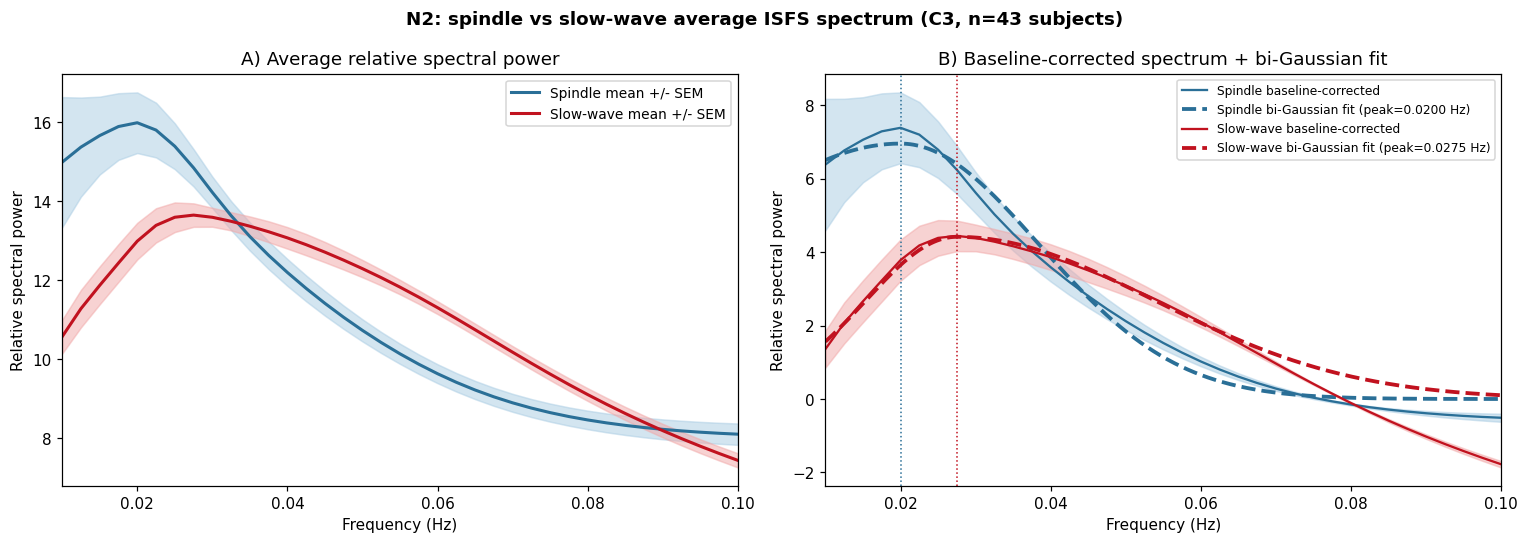

In [13]:
n2_spectral = spectral_analysis(paired_data_n2, SUBJECT_IDS_N2, EVENTS, COLORS, EVENT_LABELS,
                                 "N2", CHANNEL)

### 3.4 Phase-Locking Analysis

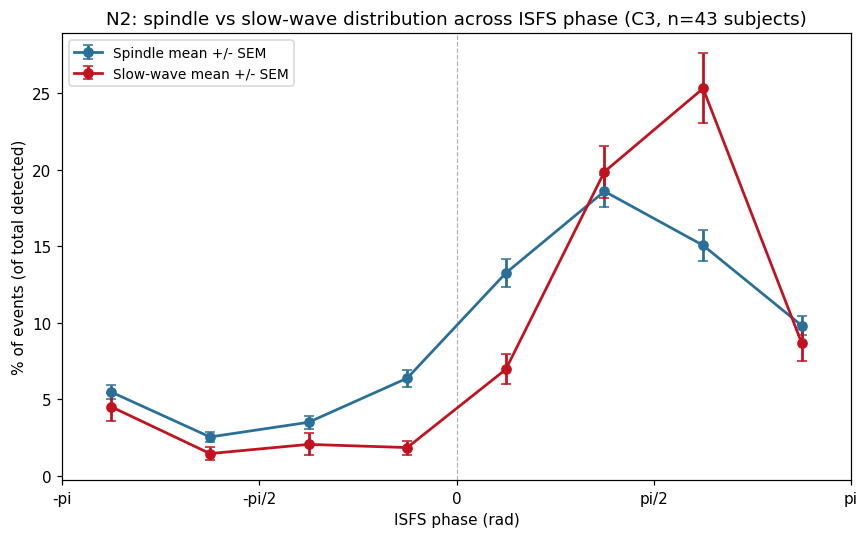

In [14]:
n2_phase = phase_analysis(paired_data_n2, SUBJECT_IDS_N2, EVENTS, COLORS, EVENT_LABELS,
                           "N2", CHANNEL)

### 3.5 Peak-Frequency Distribution

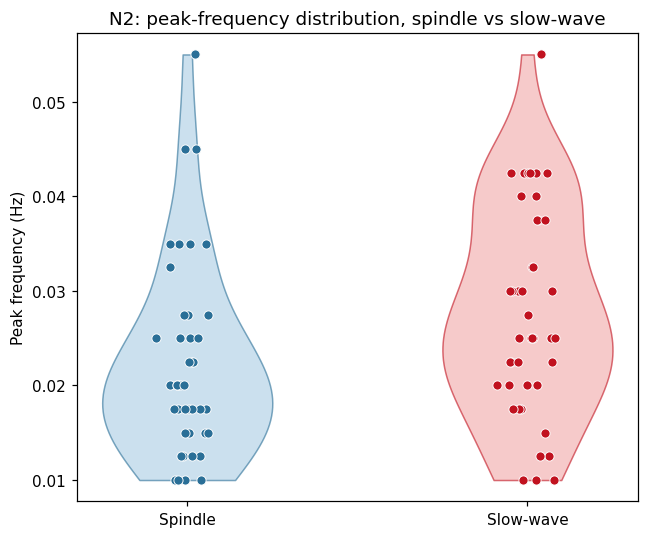

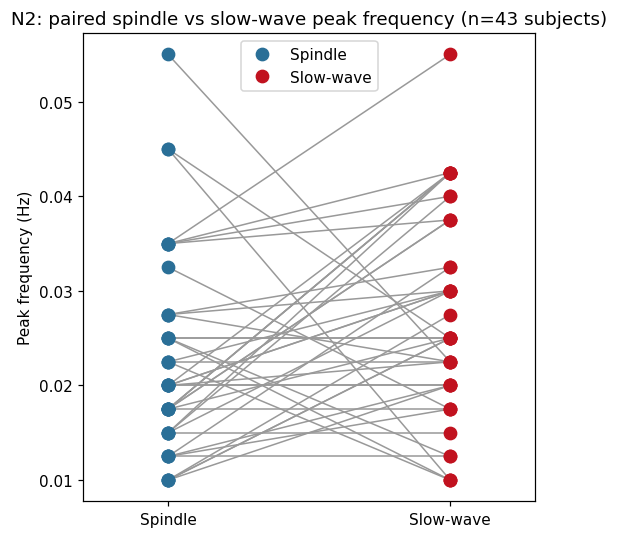

,mean,sd,median,iqr
spindle,0.022326,0.010183,0.020,0.01125
sw,0.027616,0.010897,0.025,0.01750


In [15]:
n2_peak_freqs, n2_peak_freq_summary = peak_freq_distribution(n2_dfs, EVENTS, COLORS,
                                                               EVENT_LABELS, "N2")
n2_peak_freq_summary

### 3.6 Statistical Comparison

In [16]:
n2_peak_ttest, n2_peak_dz = peak_freq_ttest(n2_dfs, EVENTS, EVENT_LABELS, "N2")

[N2] n=43 | Spindle 0.0223+/-0.0102 Hz | Slow-wave 0.0276+/-0.0109 Hz | mean diff=-0.0053 Hz | t=-2.341 | p=0.02408 | Cohen's dz=-0.357


In [17]:
n2_phase_bin_results = phase_bin_comparison(n2_phase["phase_rates"], n2_phase["bin_centers"],
                                             EVENTS)
n2_phase_bin_results

,phase_bin,phase_center,N2_mean,N3_mean,mean_difference,n_pairs,t_stat,p_value,q_value,significant_FDR
0,1,-2.748894,5.483344,4.520986,0.962358,43,1.118703,2.696247e-01,0.359500,False
1,2,-1.963495,2.555501,1.472210,1.083292,43,2.541298,1.482536e-02,0.029651,True
2,3,-1.178097,3.514686,2.071479,1.443207,43,1.652362,1.059184e-01,0.169469,False
3,4,-0.392699,6.391121,1.863410,4.527711,43,6.215118,1.947267e-07,0.000002,True
4,5,0.392699,13.250678,6.966927,6.283751,43,4.667568,3.108982e-05,0.000124,True
5,6,1.178097,18.580159,19.860778,-1.280619,43,-0.667971,5.078065e-01,0.507807,False
6,7,1.963495,15.056264,25.293939,-10.237675,43,-3.915695,3.251233e-04,0.000867,True
7,8,2.748894,9.825627,8.684275,1.141353,43,0.930398,3.574822e-01,0.408551,False


In [18]:
n2_isfs_metric_results = isfs_metric_comparison(n2_dfs, EVENTS)
n2_isfs_metric_results

,Metric,N2 Mean,N2 SD,N3 Mean,N3 SD,Mean Difference,t,p,n_pairs,Cohen's dz,q
0,peak_frequency_hz,0.022326,0.010183,0.027616,0.010897,-0.005291,-2.340599,0.024076,43,-0.356938,0.038522
1,peak_period_s,53.413305,22.028058,43.483723,21.293192,9.929583,2.076207,0.044032,43,0.316619,0.058710
2,amplitude,9.906683,9.566897,5.640853,2.798795,4.265830,3.051780,0.003934,43,0.465392,0.011789
3,sd_left,0.016820,0.015041,0.010772,0.009228,0.006047,2.485751,0.016992,43,0.379074,0.033984
4,sd_right,0.016292,0.008649,0.023316,0.013207,-0.007023,-3.008727,0.004421,43,-0.458827,0.011789
5,bandwidth_hz,0.033112,0.017855,0.034088,0.015965,-0.000976,-0.276961,0.783168,43,-0.042236,0.783168
6,auc,0.247931,0.173947,0.150275,0.072965,0.097656,3.572759,0.000903,43,0.544841,0.007223
7,chromatogram_peak_area,0.091058,0.083917,0.087436,0.054666,0.003622,0.309042,0.758818,43,0.047128,0.783168


In [19]:
n2_circ = circular_phase_supplement(n2_dfs, EVENTS, EVENT_LABELS, "N2")

[N2] Valid (non-NaN) mean_phase: Spindle 43/43 subjects
[N2] Spindle circular mean phase = 1.398 rad, resultant length = 0.964
[N2] Valid (non-NaN) mean_phase: Slow-wave 43/43 subjects
[N2] Slow-wave circular mean phase = 1.740 rad, resultant length = 0.826


## 4. N3: Spindle vs Slow-Wave

Everything below reuses the same helper functions from Section 2 with `state="N3"` --
an independent subject pool from N2 (a subject need only be usable for both events within
N3, not also in N2).

### 4.1 Find Eligible Subjects

In [20]:
paired_data_n3, SUBJECT_IDS_N3 = find_paired_event_data(
    DATA_DIR, CHANNEL, "N3", EVENTS, n_subjects=N_SUBJECTS, candidate_limit=CANDIDATE_LIMIT,
    verbose=verbose,
)

[N3][1] 317497: not paired (missing/failed an event) -- 0 paired, 0 usable so far
[N3][2] 317947: not paired (missing/failed an event) -- 0 paired, 0 usable so far
[N3][3] 318517: not paired (missing/failed an event) -- 0 paired, 0 usable so far
[N3][4] 318562: not paired (missing/failed an event) -- 0 paired, 0 usable so far
[N3][5] 318619: not paired (missing/failed an event) -- 0 paired, 0 usable so far
[N3][6] 318658: not paired (missing/failed an event) -- 0 paired, 0 usable so far
[N3][7] 318661: not paired (missing/failed an event) -- 0 paired, 0 usable so far
[N3][8] 318667: not paired (missing/failed an event) -- 0 paired, 0 usable so far
[N3][9] 318668: paired, usable -- 1 paired, 1/2000 usable so far
[N3][10] 318679: not paired (missing/failed an event) -- 1 paired, 1 usable so far
[N3][11] 320749: not paired (missing/failed an event) -- 1 paired, 1 usable so far
[N3][12] 320750: not paired (missing/failed an event) -- 1 paired, 1 usable so far
[N3][13] 320753: not paired (m

[N3][27] 322590: paired, not usable -- 3 paired, 1/2000 usable so far
[N3][28] 322591: not paired (missing/failed an event) -- 3 paired, 1 usable so far
[N3][29] 322592: not paired (missing/failed an event) -- 3 paired, 1 usable so far
[N3][30] 322595: not paired (missing/failed an event) -- 3 paired, 1 usable so far
[N3][31] 324384: paired, not usable -- 4 paired, 1/2000 usable so far
[N3][32] 324385: not paired (missing/failed an event) -- 4 paired, 1 usable so far
[N3][33] 324386: not paired (missing/failed an event) -- 4 paired, 1 usable so far
[N3][34] 324389: paired, usable -- 5 paired, 2/2000 usable so far
[N3][35] 324390: not paired (missing/failed an event) -- 5 paired, 2 usable so far
[N3][36] 324391: paired, not usable -- 6 paired, 2/2000 usable so far
[N3][37] 324392: not paired (missing/failed an event) -- 6 paired, 2 usable so far
[N3][38] 324394: not paired (missing/failed an event) -- 6 paired, 2 usable so far
[N3][39] 324395: not paired (missing/failed an event) -- 6 p

### 4.2 Load Subject Data

In [21]:
n3_dfs = load_event_dataframes(paired_data_n3, SUBJECT_IDS_N3, EVENTS)

event_dfs shapes: {'spindle': (3, 35), 'sw': (3, 35)}


### 4.3 ISFS Spectral Analysis

[N3] Spindle group fit: peak=0.0525 Hz (~19 s) | bandwidth=0.0139 Hz | detected=True
[N3] Slow-wave group fit: peak=0.0350 Hz (~29 s) | bandwidth=0.0266 Hz | detected=True


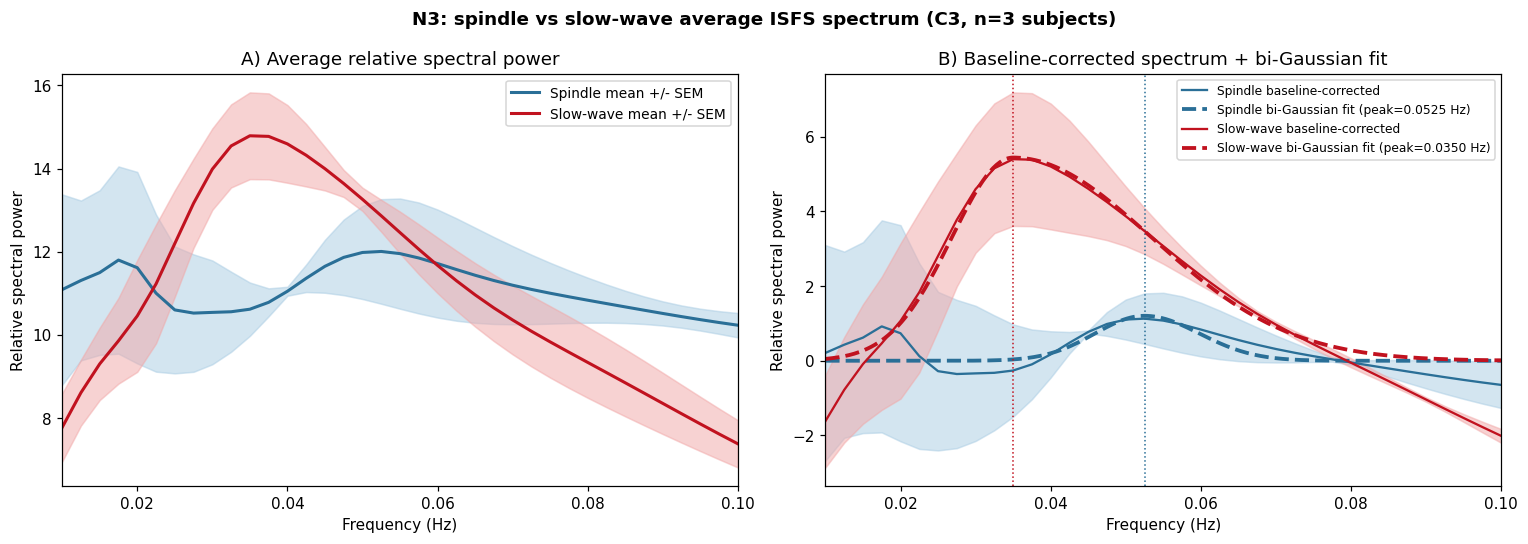

In [22]:
n3_spectral = spectral_analysis(paired_data_n3, SUBJECT_IDS_N3, EVENTS, COLORS, EVENT_LABELS,
                                 "N3", CHANNEL)

### 4.4 Phase-Locking Analysis

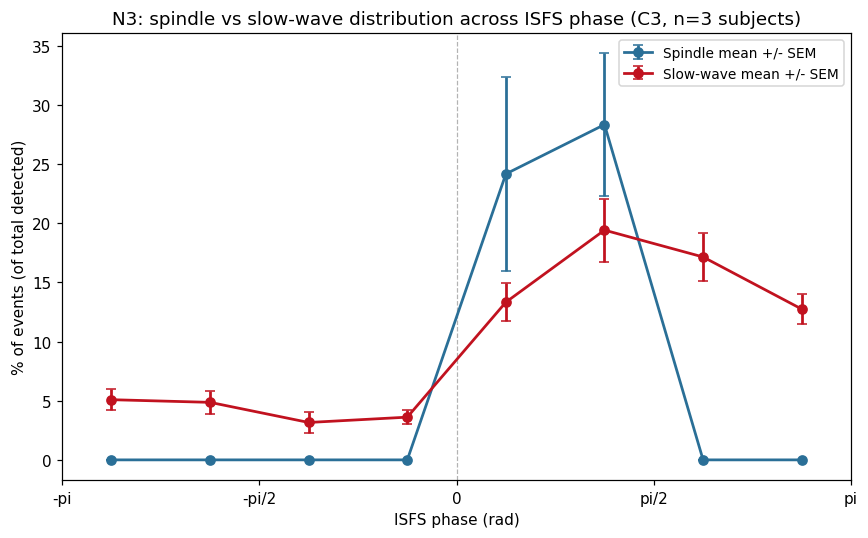

In [23]:
n3_phase = phase_analysis(paired_data_n3, SUBJECT_IDS_N3, EVENTS, COLORS, EVENT_LABELS,
                           "N3", CHANNEL)

### 4.5 Peak-Frequency Distribution

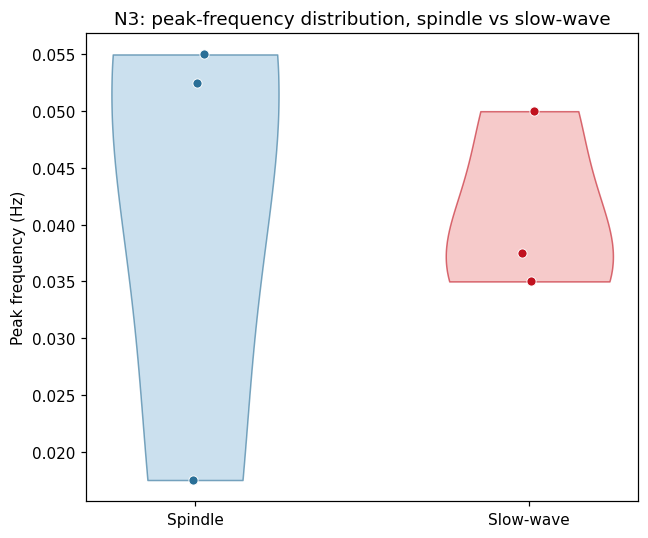

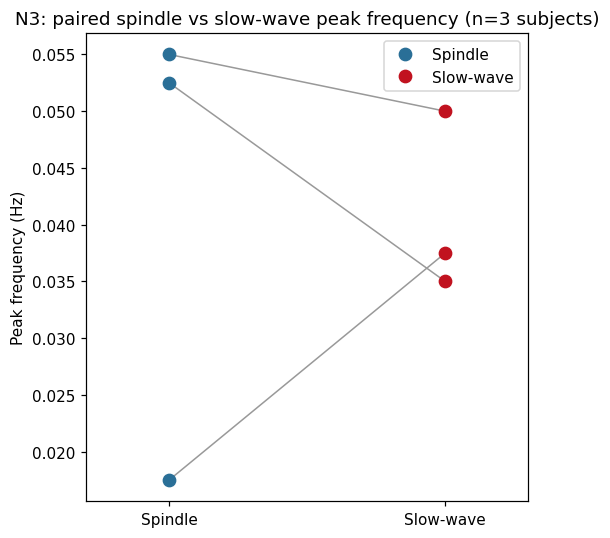

,mean,sd,median,iqr
spindle,0.041667,0.020966,0.0525,0.01875
sw,0.040833,0.008036,0.0375,0.00750


In [24]:
n3_peak_freqs, n3_peak_freq_summary = peak_freq_distribution(n3_dfs, EVENTS, COLORS,
                                                               EVENT_LABELS, "N3")
n3_peak_freq_summary

### 4.6 Statistical Comparison

In [25]:
n3_peak_ttest, n3_peak_dz = peak_freq_ttest(n3_dfs, EVENTS, EVENT_LABELS, "N3")

[N3] n=3 | Spindle 0.0417+/-0.0210 Hz | Slow-wave 0.0408+/-0.0080 Hz | mean diff=0.0008 Hz | t=0.076 | p=0.9466 | Cohen's dz=0.044


In [26]:
n3_phase_bin_results = phase_bin_comparison(n3_phase["phase_rates"], n3_phase["bin_centers"],
                                             EVENTS)
n3_phase_bin_results

,phase_bin,phase_center,N2_mean,N3_mean,mean_difference,n_pairs,t_stat,p_value,q_value,significant_FDR
0,1,-2.748894,0.000000,5.085699,-5.085699,3,-5.811543,0.028355,0.056710,False
1,2,-1.963495,0.000000,4.861232,-4.861232,3,-4.922539,0.038878,0.062205,False
2,3,-1.178097,0.000000,3.160907,-3.160907,3,-3.426570,0.075633,0.100844,False
3,4,-0.392699,0.000000,3.609826,-3.609826,3,-6.130403,0.025592,0.056710,False
4,5,0.392699,24.166667,13.327647,10.839020,3,1.355500,0.308038,0.352044,False
5,6,1.178097,28.333333,19.415724,8.917610,3,1.045672,0.405468,0.405468,False
6,7,1.963495,0.000000,17.145116,-17.145116,3,-8.410708,0.013843,0.055374,False
7,8,2.748894,0.000000,12.743512,-12.743512,3,-9.933466,0.009983,0.055374,False


In [27]:
n3_isfs_metric_results = isfs_metric_comparison(n3_dfs, EVENTS)
n3_isfs_metric_results

,Metric,N2 Mean,N2 SD,N3 Mean,N3 SD,Mean Difference,t,p,n_pairs,Cohen's dz,q
0,peak_frequency_hz,0.041667,0.020966,0.040833,0.008036,0.000833,0.075593,0.946624,3,0.043644,0.946624
1,peak_period_s,31.457431,22.248443,25.079365,4.500777,6.378066,0.520545,0.654576,3,0.300537,0.946624
2,amplitude,3.181421,2.215547,5.713689,2.578693,-2.532268,-2.616146,0.120305,3,-1.510433,0.417199
3,sd_left,0.020441,0.025599,0.011585,0.003420,0.008857,0.679238,0.567053,3,0.392159,0.946624
4,sd_right,0.008155,0.003856,0.013241,0.001999,-0.005086,-2.816705,0.106318,3,-1.626225,0.417199
5,bandwidth_hz,0.028596,0.029288,0.024826,0.003700,0.003770,0.255139,0.822456,3,0.147305,0.946624
6,auc,0.113281,0.163342,0.126494,0.075130,-0.013213,-0.239751,0.832855,3,-0.138420,0.946624
7,chromatogram_peak_area,0.011983,0.008831,0.106958,0.082204,-0.094975,-2.221322,0.156450,3,-1.282481,0.417199


In [28]:
n3_circ = circular_phase_supplement(n3_dfs, EVENTS, EVENT_LABELS, "N3")

[N3] Valid (non-NaN) mean_phase: Spindle 3/3 subjects
[N3] Spindle circular mean phase = 0.831 rad, resultant length = 0.992
[N3] Valid (non-NaN) mean_phase: Slow-wave 3/3 subjects
[N3] Slow-wave circular mean phase = 1.592 rad, resultant length = 0.994


## 5. Summary

In [29]:
def _n_sig(results_df):
    if "significant_FDR" in results_df.columns:
        return int(results_df["significant_FDR"].sum()), len(results_df)
    return int((results_df["q"] < 0.05).sum()), len(results_df)


print("Summary")
print("=======")
for state, dfs, peak_ttest, peak_dz, phase_bin_results, isfs_metric_results, circ in (
    ("N2", n2_dfs, n2_peak_ttest, n2_peak_dz, n2_phase_bin_results, n2_isfs_metric_results, n2_circ),
    ("N3", n3_dfs, n3_peak_ttest, n3_peak_dz, n3_phase_bin_results, n3_isfs_metric_results, n3_circ),
):
    n_sig_bins, n_bins = _n_sig(phase_bin_results)
    n_sig_metrics, n_metrics = _n_sig(isfs_metric_results)
    print(f"--- {state} ---")
    print(f"Subjects: {len(dfs['spindle'])} (channel {CHANNEL}), paired spindle/sw usable data")
    print(f"Peak frequency: spindle {peak_ttest['x_mean']:.4f} Hz vs sw "
          f"{peak_ttest['y_mean']:.4f} Hz, t({peak_ttest['n_pairs'] - 1})="
          f"{peak_ttest['t_stat']:.3f}, p={peak_ttest['p_value']:.4g}, Cohen's dz={peak_dz:.3f}")
    print(f"Phase bins significant after FDR (q<0.05): {n_sig_bins}/{n_bins}")
    print(f"ISFS metrics significant after FDR (q<0.05): {n_sig_metrics}/{n_metrics}")
    print(f"Spindle circular mean phase: {circ['spindle'][0]:.3f} rad "
          f"(resultant {circ['spindle'][1]:.3f})")
    print(f"Slow-wave circular mean phase: {circ['sw'][0]:.3f} rad "
          f"(resultant {circ['sw'][1]:.3f})")

Summary
--- N2 ---
Subjects: 43 (channel C3), paired spindle/sw usable data
Peak frequency: spindle 0.0223 Hz vs sw 0.0276 Hz, t(42)=-2.341, p=0.02408, Cohen's dz=-0.357
Phase bins significant after FDR (q<0.05): 4/8
ISFS metrics significant after FDR (q<0.05): 5/8
Spindle circular mean phase: 1.398 rad (resultant 0.964)
Slow-wave circular mean phase: 1.740 rad (resultant 0.826)
--- N3 ---
Subjects: 3 (channel C3), paired spindle/sw usable data
Peak frequency: spindle 0.0417 Hz vs sw 0.0408 Hz, t(2)=0.076, p=0.9466, Cohen's dz=0.044
Phase bins significant after FDR (q<0.05): 0/8
ISFS metrics significant after FDR (q<0.05): 0/8
Spindle circular mean phase: 0.831 rad (resultant 0.992)
Slow-wave circular mean phase: 1.592 rad (resultant 0.994)
